#### Bloque Ejemplo 1 – Plan agregado gráfico  Proveedor de materiales para tejados (Juárez, México)
####  Datos de entrada
#### Demanda mensual (enero–junio): [900, 700, 900, 1200, 1500, 1000]
#### Días laborables por mes: [22, 18, 21, 21, 22, 20]
#### Inventario inicial: 0
#### Inventario final deseado: 0
#### Capacidad media: 50 unidades/día (calculada como 6.200 ÷ 124 días).


           Mes  Demanda  Días  Demanda por día  Producción  Inventario Final
0        Enero      900    22            40.91      1100.0             200.0
1      Febrero      700    18            38.89       900.0             400.0
2        Marzo      900    21            42.86      1050.0             550.0
3        Abril     1200    21            57.14      1050.0             400.0
4         Mayo     1500    22            68.18      1100.0               0.0
5        Junio     1000    20            50.00      1000.0               0.0
Total    Total     6200   124            50.00      6200.0               0.0


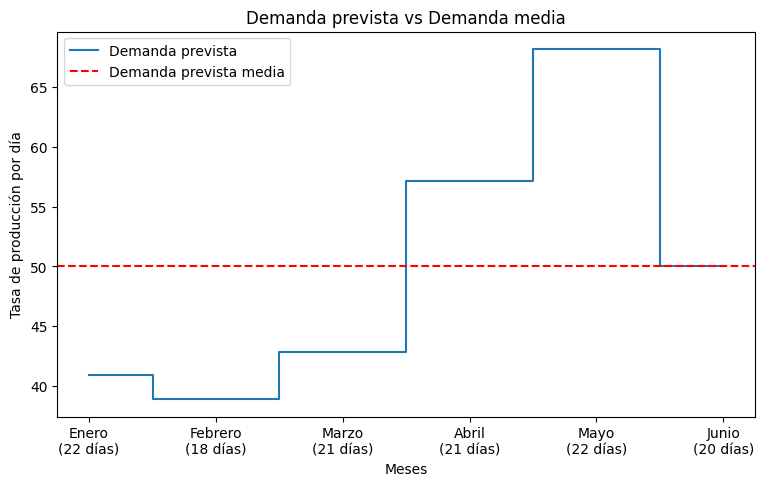

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

def ejemplo1_plan_agregado(demanda, dias_mes, empleados, horas_por_unidad, costos):
    """
    Ejemplo 1: Presentación gráfica de un plan agregado.
    Incluye columna de demanda calculada por día y totales al final.
    """
    produccion_diaria = (8 / horas_por_unidad) * empleados
    resultados = []

    # Lista de nombres de meses
    meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"]

    inventario = 0
    for mes_nombre, (d, dias) in zip(meses, zip(demanda, dias_mes)):
        produccion_mes = produccion_diaria * dias
        inventario = inventario + produccion_mes - d
        demanda_por_dia = d / dias
        resultados.append({
            "Mes": mes_nombre,
            "Demanda": d,
            "Días": dias,
            "Demanda por día": round(demanda_por_dia, 2),
            "Producción": produccion_mes,
            "Inventario Final": inventario
        })

    df = pd.DataFrame(resultados)

    # Agregar fila de totales
    total_demanda = sum(demanda)
    total_dias = sum(dias_mes)
    df.loc["Total"] = {
        "Mes": "Total",
        "Demanda": total_demanda,
        "Días": total_dias,
        "Demanda por día": round(total_demanda / total_dias, 2),
        "Producción": df["Producción"].sum(),
        "Inventario Final": df["Inventario Final"].iloc[-1]
    }

    return df

def graficar_ejemplo1(df):
    """
    Grafica la demanda prevista por día y la demanda media.
    """
    plt.figure(figsize=(9,5))
    # Excluir la fila de totales para el gráfico
    df_plot = df.drop("Total")
    plt.step(df_plot["Mes"], df_plot["Demanda por día"], where="mid", label="Demanda prevista")
    plt.axhline(y=df.loc["Total","Demanda por día"], color="red", linestyle="--", label="Demanda prevista media")
    # Etiquetas con meses y días
    plt.xticks(df_plot["Mes"], [f"{m}\n({d} días)" for m, d in zip(df_plot["Mes"], df_plot["Días"])])
    plt.xlabel("Meses")
    plt.ylabel("Tasa de producción por día")
    plt.title("Demanda prevista vs Demanda media")
    plt.legend()
    plt.show()

# Datos del Ejemplo 1
demanda = [900, 700, 900, 1200, 1500, 1000]
dias_mes = [22, 18, 21, 21, 22, 20]
costos = {"inventario": 5, "salario": 40}

# Caso con 10 empleados
df_plan = ejemplo1_plan_agregado(demanda, dias_mes, empleados=10, horas_por_unidad=1.6, costos=costos)

print(df_plan)

graficar_ejemplo1(df_plan)


####  Ejemplo 2 – Plan 1: plantilla constante
#### Costos relevantes (TABLA 3.3):
#### Almacenamiento: 5 $/unidad/mes.
#### Subcontratación: 10 $/unidad.
#### Salario medio: 5 $/hora (40 $/día).
#### Hora extra: 7 $/hora (>8 horas/día).
#### Mano de obra: 1.6 horas/unidad.
#### Contratación: 300 $/unidad/día adicional.
#### Despido: 600 $/unidad/día reducida


In [ ]:
import pandas as pd

def plan1_constante(demanda, dias_mes, horas_por_unidad, costos):
    """
    Plan 1: producción constante de 50 unidades/día (10 empleados).
    """
    empleados = 10
    produccion_diaria = 50  # fijo según el análisis
    resultados = []
    inventario = 0
    inventario_total = 0

    meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"]

    for mes_nombre, (d, dias) in zip(meses, zip(demanda, dias_mes)):
        produccion_mes = produccion_diaria * dias
        inventario = inventario + produccion_mes - d
        inventario_total += max(0, inventario)  # acumulamos solo inventario positivo
        valoracion = produccion_mes - d
        resultados.append({
            "Mes": mes_nombre,
            "Producción a 50 unidades/día": produccion_mes,
            "Demanda estimada": d,
            "Valoración mensual del inventario": valoracion,
            "Inventario final": inventario
        })

    df = pd.DataFrame(resultados)

    # Totales
    df.loc["Total"] = {
        "Mes": "Total",
        "Producción a 50 unidades/día": df["Producción a 50 unidades/día"].sum(),
        "Demanda estimada": sum(demanda),
        "Valoración mensual del inventario": "",
        "Inventario final": inventario_total
    }

    # Cálculo de costes
    coste_inventario = inventario_total * costos["inventario"]
    coste_mano_obra = empleados * costos["salario"] * sum(dias_mes)
    coste_total = coste_inventario + coste_mano_obra

    tabla_costes = pd.DataFrame([
        {"Concepto": "Inventario", "Cálculo": f"{inventario_total} unidades * {costos['inventario']}$", "Coste": coste_inventario},
        {"Concepto": "Mano de obra regular", "Cálculo": f"{empleados} empleados * {costos['salario']}$ * {sum(dias_mes)} días", "Coste": coste_mano_obra},
        {"Concepto": "Otros costes", "Cálculo": "Horas extras, contratación, despidos, subcontratación", "Coste": 0},
        {"Concepto": "Total", "Cálculo": "", "Coste": coste_total}
    ])

    return df, tabla_costes

# Datos del Plan 1
demanda = [900, 700, 900, 1200, 1500, 1000]
dias_mes = [22, 18, 21, 21, 22, 20]
costos = {"inventario": 5, "salario": 40}

df_plan1, tabla_costes1 = plan1_constante(demanda, dias_mes, horas_por_unidad=1.6, costos=costos)

print("=== Tabla de Producción vs Demanda (Plan 1) ===")
print(df_plan1)
print("\n=== Tabla de Costes (Plan 1) ===")
print(tabla_costes1)
